# pytorch.org/vision/stable/datasets.html

In [1]:
# import packages
import torch
from torchvision import datasets, transforms
from torchvision.transforms import ToTensor
from torch.utils.data  import DataLoader

from matplotlib import pyplot as plt



In [2]:
training_data = datasets.FashionMNIST(

          root="data",
          train=True,
          download=True,      
          transform=ToTensor()

)



In [3]:
# size of training data

len(training_data)

60000

In [4]:
test_data = datasets.FashionMNIST(

          root="data",
          train=False,
          download=True,      
          transform=ToTensor()

)

In [5]:
# size of test data
len(test_data)

10000

In [6]:
# get the image and label of the first training sample
image, label = training_data[0]

image.shape, label

(torch.Size([1, 28, 28]), 9)

In [7]:
# acutally it is a 28*28 but it added extrat dimension for channel, so it is 1*28*28
# hence get rid of it by using squeeze() function

image.squeeze().shape, label

(torch.Size([28, 28]), 9)

In [8]:
image

tensor([[[0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000],
         [0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000, 0.0000,
          0.0000, 0.0000, 0.0000, 0.0000, 0.0039, 0.0000, 0.0000, 0.0510,
          0.2863, 0.0000, 0.0000, 0.0039, 0.0157, 0.0000,

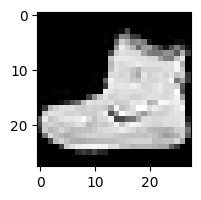

In [9]:
# show the image using matplotlib

plt.figure(figsize=(2,2))
plt.imshow(image.squeeze(), cmap='gray')
plt.show()

In [10]:
labels_map = {
          0: "T-shirt/top",
          1: "Trouser",
          2: "Pullover",
          3: "Dress",
          4: "Coat",
          5: "Sandal",
          6: "Shirt",
          7: "Sneaker",
          8: "Bag",
          9: "Ankle boot"
}

In [11]:
labels_map[label]

'Ankle boot'

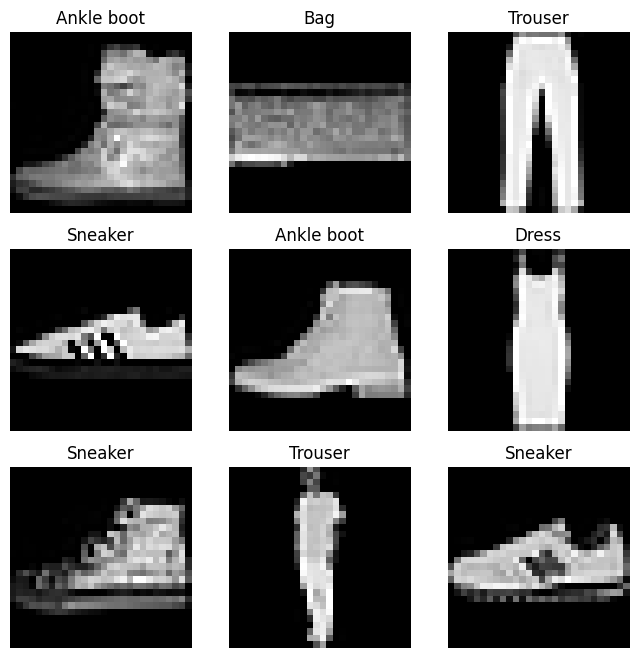

In [12]:
#show couple of lables and along with their images

plt.figure(figsize=(8,8))
cols , rows = 3, 3
for i in range(1,cols*rows+1):
          sample_idx = torch.randint(len(training_data), size=(1,)).item() # random value from the range of training data with size of 1 and get the value using item() function (tensor to scalar)
          image, label = training_data[sample_idx]
          plt.subplot(rows, cols, i)
          plt.imshow(image.squeeze(), cmap='gray')
          plt.title(labels_map[label])
          plt.axis('off')

In [13]:
# using DataLoader to load the training data in batches

train_dataloader = DataLoader(training_data, batch_size=64, shuffle=True)

#using DataLoader to load the test data in batches


test_dataloader = DataLoader(test_data, batch_size=64, shuffle=True)


In [14]:
type(train_dataloader), type(test_dataloader)

(torch.utils.data.dataloader.DataLoader,
 torch.utils.data.dataloader.DataLoader)

In [15]:
data_iter = iter(train_dataloader)

images, lables = next(data_iter)

In [19]:
data_iter.__sizeof__

<function _SingleProcessDataLoaderIter.__sizeof__()>

In [16]:
images.shape , lables.shape

(torch.Size([64, 1, 28, 28]), torch.Size([64]))

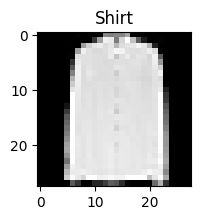

In [18]:
# show the image using matplotlib

plt.figure(figsize=(2,2))
plt.imshow(images[0].squeeze(), cmap='gray')
plt.title(labels_map[lables[0].item()])
plt.show()